
we are making a model which will predict the future trends from previous data of stock market so I will explain whhat are we going to do in these ps 

In [37]:
!pip install numpy

In [38]:
import numpy as  np

In [39]:
!pip install pandas

In [40]:
import pandas as pd

In [41]:
!pip install matplotlib

In [42]:
import matplotlib.pyplot as plo

In [43]:
!pip install yfinance

In [44]:
import yfinance as yf

In [45]:
stockdata = yf.download("AAPL",start="2020-01-01",end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [46]:
data_pd=pd.DataFrame(stockdata)#to convert other types of data into dataframes that is in type of tables of pandas here no need as it is alreasdy in datafrane

In [47]:
data_pd.head(1)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.468277,72.528597,71.223274,71.476615,135480400


In [48]:
data_pd.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [49]:
x=stockdata.index

In [50]:
y=stockdata["Close"]

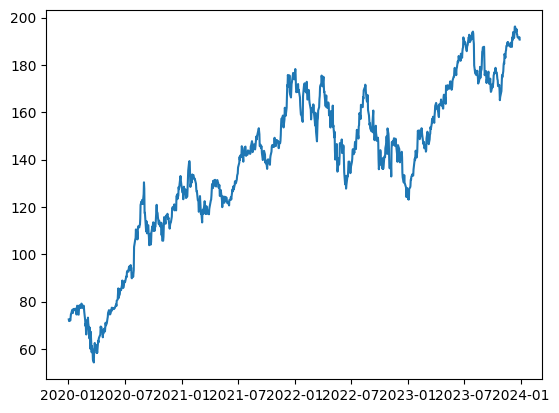

In [51]:
plo.plot(x,y)

In [52]:
stockdata["Close"].rolling(window=20).mean()

Ticker,AAPL
Date,
2020-01-02,NaN
2020-01-03,NaN
2020-01-06,NaN
2020-01-07,NaN
2020-01-08,NaN
...,...
2023-12-22,191.856624
2023-12-26,192.018099
2023-12-27,192.154312


In [53]:
x=stockdata.index
y1=stockdata["Close"]
y2=stockdata["Close"].rolling(window=20).mean()


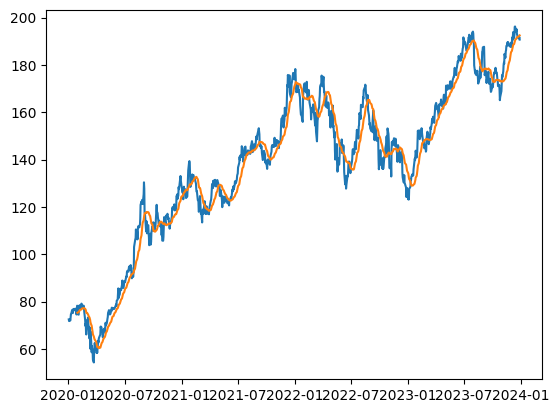

In [54]:
plo.plot(x,y1)
plo.plot(x,y2)

In [55]:
rsdata=stockdata.reset_index()

In [56]:
stockdata["Close"]

Ticker,AAPL
Date,
2020-01-02,72.468277
2020-01-03,71.763710
2020-01-06,72.335541
2020-01-07,71.995361
2020-01-08,73.153488
...,...
2023-12-22,191.788773
2023-12-26,191.243896
2023-12-27,191.342957


In [57]:
ds=rsdata["Date"]

In [58]:
stockdata["Close"]


Ticker,AAPL
Date,
2020-01-02,72.468277
2020-01-03,71.763710
2020-01-06,72.335541
2020-01-07,71.995361
2020-01-08,73.153488
...,...
2023-12-22,191.788773
2023-12-26,191.243896
2023-12-27,191.342957


In [59]:
z=rsdata["Close"]

In [60]:
y=z.squeeze()

In [61]:
print(y)

0        72.468277
1        71.763710
2        72.335541
3        71.995361
4        73.153488
           ...    
1001    191.788773
1002    191.243896
1003    191.342957
1004    191.768936
1005    190.728760
Name: AAPL, Length: 1006, dtype: float64


In [62]:
print(ds)

0      2020-01-02
1      2020-01-03
2      2020-01-06
3      2020-01-07
4      2020-01-08
          ...    
1001   2023-12-22
1002   2023-12-26
1003   2023-12-27
1004   2023-12-28
1005   2023-12-29
Name: Date, Length: 1006, dtype: datetime64[ns]


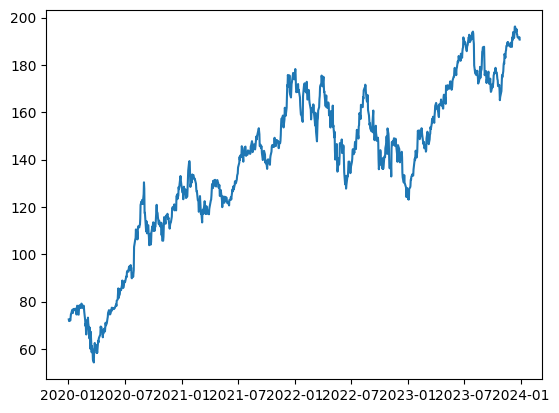

In [63]:
plo.plot(ds,y)

In [64]:
new_form_data=(ds,y)

In [65]:
p_data=rsdata.drop(columns=["High","Low","Volume","Open"])

C:\Users\imran\AppData\Local\Temp\ipykernel_31364\712812369.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  p_data=rsdata.drop(columns=["High","Low","Volume","Open"])


In [66]:
print(p_data)

Price        Date       Close
Ticker                   AAPL
0      2020-01-02   72.468277
1      2020-01-03   71.763710
2      2020-01-06   72.335541
3      2020-01-07   71.995361
4      2020-01-08   73.153488
...           ...         ...
1001   2023-12-22  191.788773
1002   2023-12-26  191.243896
1003   2023-12-27  191.342957
1004   2023-12-28  191.768936
1005   2023-12-29  190.728760

[1006 rows x 2 columns]


In [67]:
print(ds)

0      2020-01-02
1      2020-01-03
2      2020-01-06
3      2020-01-07
4      2020-01-08
          ...    
1001   2023-12-22
1002   2023-12-26
1003   2023-12-27
1004   2023-12-28
1005   2023-12-29
Name: Date, Length: 1006, dtype: datetime64[ns]


In [68]:
prophet_data=pd.DataFrame({"ds":ds,"y":y})

In [69]:
print(prophet_data)

             ds           y
0    2020-01-02   72.468277
1    2020-01-03   71.763710
2    2020-01-06   72.335541
3    2020-01-07   71.995361
4    2020-01-08   73.153488
...         ...         ...
1001 2023-12-22  191.788773
1002 2023-12-26  191.243896
1003 2023-12-27  191.342957
1004 2023-12-28  191.768936
1005 2023-12-29  190.728760

[1006 rows x 2 columns]


In [70]:
p_data.rename(columns={"Date":"ds","Close":"y"})

Price,ds,y
Ticker,,AAPL
0,2020-01-02,72.468277
1,2020-01-03,71.763710
2,2020-01-06,72.335541
3,2020-01-07,71.995361
4,2020-01-08,73.153488
...,...,...
1001,2023-12-22,191.788773
1002,2023-12-26,191.243896
1003,2023-12-27,191.342957


In [71]:
!pip install prophet

In [72]:
from prophet import Prophet

In [73]:
mode1=Prophet()

In [74]:
mode1.fit(prophet_data)

00:06:15 - cmdstanpy - INFO - Chain [1] start processing
00:06:16 - cmdstanpy - INFO - Chain [1] done processing


In [75]:
future_data=mode1.make_future_dataframe(periods=7)

In [77]:
future_data.head()


,ds
0,2020-01-02
1,2020-01-03
2,2020-01-06
3,2020-01-07
4,2020-01-08


In [81]:
future_data.tail(7)

,ds
1006,2023-12-30
1007,2023-12-31
1008,2024-01-01
1009,2024-01-02
1010,2024-01-03
1011,2024-01-04
1012,2024-01-05


In [80]:
print(future_data)

             ds
0    2020-01-02
1    2020-01-03
2    2020-01-06
3    2020-01-07
4    2020-01-08
...         ...
1008 2024-01-01
1009 2024-01-02
1010 2024-01-03
1011 2024-01-04
1012 2024-01-05

[1013 rows x 1 columns]


In [84]:
forecast=mode1.predict(future_data)

In [89]:
last_10days=forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(10)

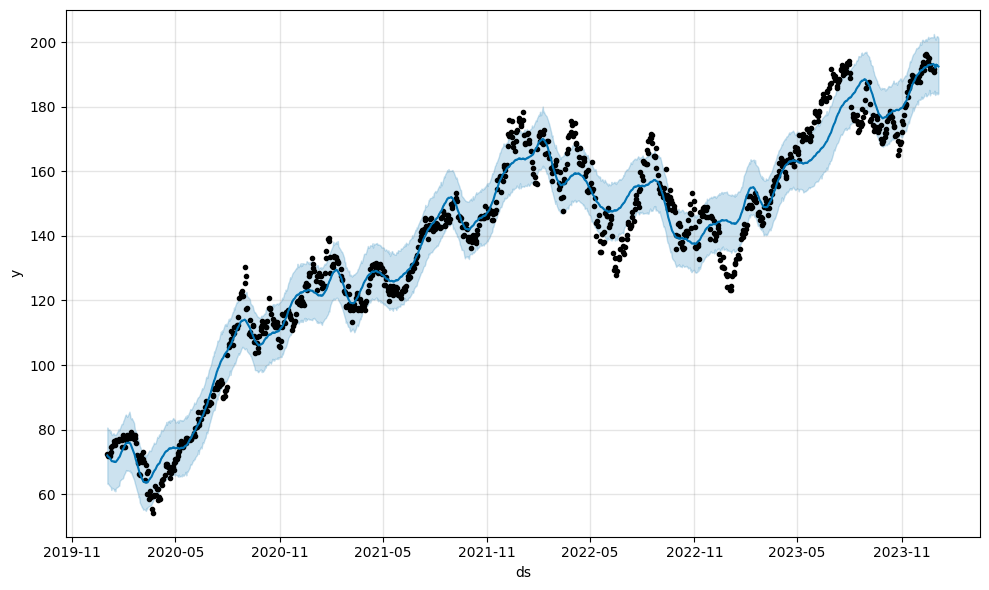

In [90]:
fig=mode1.plot(forecast)

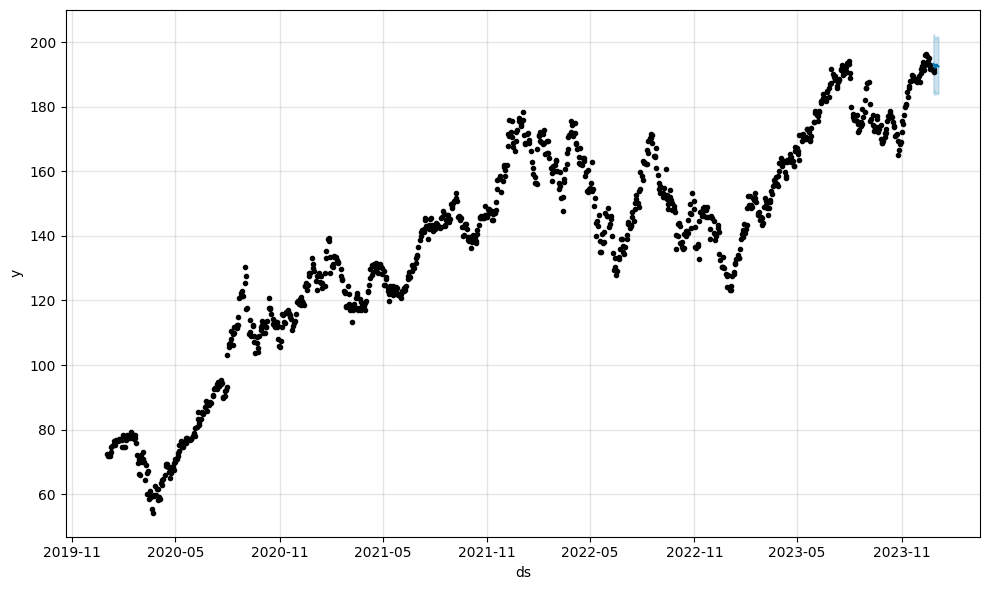

In [91]:
fig=mode1.plot(last_10days)

In [92]:
print(last_10days)

             ds        yhat  yhat_lower  yhat_upper
1003 2023-12-27  193.221009  183.950769  201.454639
1004 2023-12-28  193.013480  184.160583  202.497728
1005 2023-12-29  192.922928  184.939990  201.672162
1006 2023-12-30  192.096013  183.596729  201.154103
1007 2023-12-31  192.034450  183.818249  200.711051
1008 2024-01-01  193.029926  184.418794  201.294211
1009 2024-01-02  192.815697  183.856068  201.831223
1010 2024-01-03  192.818963  184.356602  201.744773
1011 2024-01-04  192.553746  183.822388  201.656466
1012 2024-01-05  192.422769  184.098234  201.049731


In [97]:
print(prophet_data)

             ds           y
0    2020-01-02   72.468277
1    2020-01-03   71.763710
2    2020-01-06   72.335541
3    2020-01-07   71.995361
4    2020-01-08   73.153488
...         ...         ...
1001 2023-12-22  191.788773
1002 2023-12-26  191.243896
1003 2023-12-27  191.342957
1004 2023-12-28  191.768936
1005 2023-12-29  190.728760

[1006 rows x 2 columns]


In [101]:
last10actual=prophet_data.tail(10)


In [104]:
last10predicted=forecast.tail(10)

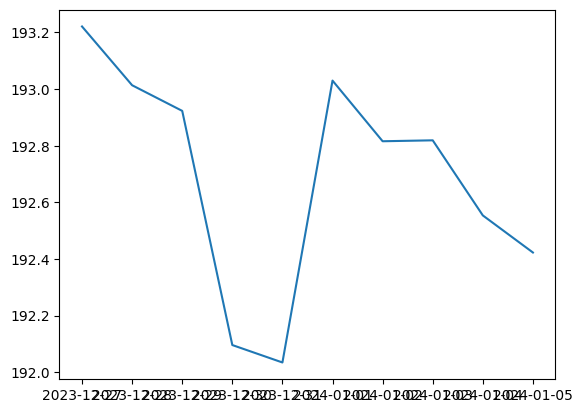

In [105]:
plo.plot(last10predicted["ds"],last10predicted["yhat"])

In [102]:
print(last10actual)

             ds           y
996  2023-12-15  195.721634
997  2023-12-18  194.057327
998  2023-12-19  195.097534
999  2023-12-20  193.007263
1000 2023-12-21  192.858658
1001 2023-12-22  191.788773
1002 2023-12-26  191.243896
1003 2023-12-27  191.342957
1004 2023-12-28  191.768936
1005 2023-12-29  190.728760


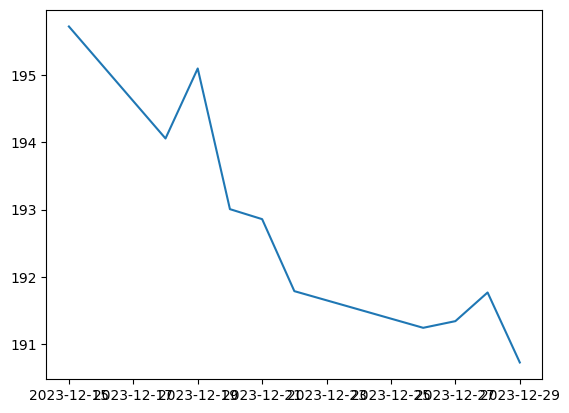

In [103]:
plo.plot(last10actual["ds"],last10actual["y"])

In [109]:
forecast_past = forecast[forecast["ds"].isin(prophet_data["ds"])]

In [110]:
acc_data=prophet_data.merge(forecast_past[["ds","yhat"]],on="ds")

In [113]:
acc_data["abs_error"] = abs(acc_data["y"] - acc_data["yhat"])

In [114]:
mae = acc_data["abs_error"].mean() 

In [115]:
print(mae)

5.126600651584248
